In [1]:
import os
import numpy as np
import pandas as pd


def build_realized_cov_har_master(
    in_path="../data/log_returns.csv",
    out_dir="../proxy",
    out_name="realized_cov_har.csv",
    target_h=21,
    lags=(5, 21, 63),
    debug=True
):
    """
    Build a master HAR covariance dataset indexed by prediction date t.

    For each valid date t, the row contains:
        - target covariance over returns[t : t+target_h]
        - lagged covariance over returns[t-lag : t] for each lag in `lags`

    Important indexing:
        - target uses returns from t ... t+20 when target_h=21
        - lag 5 uses returns from t-5 ... t-1
        - lag 21 uses returns from t-21 ... t-1
        - lag 63 uses returns from t-63 ... t-1

    So row date t means:
        "standing at date t, use only past information to predict the next 21 days."

    Parameters
    ----------
    in_path : str
        Path to CSV with columns: Date, asset1, asset2, ...
    out_dir : str
        Directory to save the output CSV
    out_name : str
        Name of output file
    target_h : int
        Forecast horizon length
    lags : tuple
        Lag window lengths to include as predictors
    debug : bool
        If True, print sanity checks

    Returns
    -------
    har_df : pd.DataFrame
        Master HAR dataset
    """

    # -----------------------------
    # 1) Load and prepare returns
    # -----------------------------
    df = pd.read_csv(in_path, parse_dates=["Date"]).sort_values("Date").set_index("Date")

    assets = df.columns.tolist()
    R = df.to_numpy()
    dates = df.index
    T, N = R.shape

    if T == 0:
        raise ValueError("Input file contains no rows.")
    if N == 0:
        raise ValueError("Input file contains no asset columns.")

    max_lag = max(lags)

    # Valid prediction dates t must satisfy:
    # t - max_lag >= first row index
    # t + target_h - 1 <= last row index
    start_k = max_lag
    end_k = T - target_h  # inclusive in loop below

    if end_k < start_k:
        raise ValueError(
            "Not enough observations to build HAR dataset. "
            f"Need more than max(lags)+target_h = {max_lag + target_h} rows."
        )

    # -----------------------------
    # 2) Column names
    # -----------------------------
    full_cov_cols = [
        f"cov_{assets[i]}__{assets[j]}"
        for i in range(N)
        for j in range(N)
    ]

    target_cols = [f"target_{c}" for c in full_cov_cols]

    lag_cols_by_lag = {
        lag: [f"lag{lag}_{c}" for c in full_cov_cols]
        for lag in lags
    }

    meta_cols = ["Date"]

    # Optional metadata columns for debugging/alignment
    for lag in lags:
        meta_cols.extend([f"lag{lag}_start", f"lag{lag}_end"])
    meta_cols.extend(["target_start", "target_end"])

    all_cols = meta_cols + target_cols
    for lag in lags:
        all_cols.extend(lag_cols_by_lag[lag])

    # -----------------------------
    # 3) Build rows
    # -----------------------------
    rows = []

    for k in range(start_k, end_k + 1):
        row = {}

        # Prediction date
        row["Date"] = dates[k]

        # -------------------------
        # Target block: [t, t+H-1]
        # -------------------------
        target_window = R[k:k + target_h]
        target_sigma = (target_window.T @ target_window) / target_h
        target_sigma = 0.5 * (target_sigma + target_sigma.T)

        row["target_start"] = dates[k]
        row["target_end"] = dates[k + target_h - 1]

        target_flat = target_sigma.flatten()
        for col, val in zip(target_cols, target_flat):
            row[col] = val

        # -------------------------
        # Lag blocks: [t-lag, t-1]
        # -------------------------
        for lag in lags:
            lag_window = R[k - lag:k]
            lag_sigma = (lag_window.T @ lag_window) / lag
            lag_sigma = 0.5 * (lag_sigma + lag_sigma.T)

            row[f"lag{lag}_start"] = dates[k - lag]
            row[f"lag{lag}_end"] = dates[k - 1]

            lag_flat = lag_sigma.flatten()
            for col, val in zip(lag_cols_by_lag[lag], lag_flat):
                row[col] = val

        rows.append(row)

    har_df = pd.DataFrame(rows, columns=all_cols)
    har_df = har_df.set_index("Date").sort_index()

    # -----------------------------
    # 4) Save
    # -----------------------------
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, out_name)
    har_df.to_csv(out_path)

    print("Saved:", out_path)
    print("Shape:", har_df.shape)
    print("Number of assets:", N)
    print("Assets:", assets)
    print("Date range:", har_df.index.min().date(), "->", har_df.index.max().date())

    # -----------------------------
    # 5) Sanity checks
    # -----------------------------
    if debug:
        print("\n--- SANITY CHECK ---")

        first_date = har_df.index[0]
        print("First prediction date t:", first_date.date())

        first_k = start_k

        # Check target
        manual_target = (R[first_k:first_k + target_h].T @ R[first_k:first_k + target_h]) / target_h
        manual_target = 0.5 * (manual_target + manual_target.T)
        stored_target = har_df.iloc[0][target_cols].to_numpy().reshape(N, N)

        target_diff = np.abs(manual_target - stored_target).max()
        print("Target window :", dates[first_k].date(), "->", dates[first_k + target_h - 1].date())
        print("Max diff target manual vs stored:", target_diff)

        # Check each lag
        for lag in lags:
            manual_lag = (R[first_k - lag:first_k].T @ R[first_k - lag:first_k]) / lag
            manual_lag = 0.5 * (manual_lag + manual_lag.T)
            stored_lag = har_df.iloc[0][lag_cols_by_lag[lag]].to_numpy().reshape(N, N)

            lag_diff = np.abs(manual_lag - stored_lag).max()
            print(f"Lag {lag} window: {dates[first_k - lag].date()} -> {dates[first_k - 1].date()}")
            print(f"Max diff lag{lag} manual vs stored:", lag_diff)

    return har_df


# ==========================================================
# RUN
# ==========================================================
har_master = build_realized_cov_har_master(
    in_path="../data/log_returns.csv",
    out_dir="../proxy",
    out_name="realized_cov_har.csv",
    target_h=21,
    lags=(5, 21, 63),
    debug=True
)

print("\nHead:")
print(har_master.head())

print("\nColumns:")
print(har_master.columns.tolist()[:20])  # first 20 columns only


# ==========================================================
# OPTIONAL: small check of one specific row
# ==========================================================
row_idx = 0
print("\n--- EXAMPLE ROW INFO ---")
print("Prediction date t:", har_master.index[row_idx].date())
print("lag5_start:", har_master.iloc[row_idx]["lag5_start"].date())
print("lag5_end  :", har_master.iloc[row_idx]["lag5_end"].date())
print("lag21_start:", har_master.iloc[row_idx]["lag21_start"].date())
print("lag21_end  :", har_master.iloc[row_idx]["lag21_end"].date())
print("lag63_start:", har_master.iloc[row_idx]["lag63_start"].date())
print("lag63_end  :", har_master.iloc[row_idx]["lag63_end"].date())
print("target_start:", har_master.iloc[row_idx]["target_start"].date())
print("target_end  :", har_master.iloc[row_idx]["target_end"].date())

Saved: ../proxy/realized_cov_har.csv
Shape: (2121, 264)
Number of assets: 8
Assets: ['US_EQUITY', 'INTL_EQUITY', 'US_BONDS', 'INTL_BONDS', 'US_REIT', 'INTL_REIT', 'GOLD', 'BTC']
Date range: 2017-06-27 -> 2025-12-02

--- SANITY CHECK ---
First prediction date t: 2017-06-27
Target window : 2017-06-27 -> 2017-07-26
Max diff target manual vs stored: 0.0
Lag 5 window: 2017-06-20 -> 2017-06-26
Max diff lag5 manual vs stored: 0.0
Lag 21 window: 2017-05-26 -> 2017-06-26
Max diff lag21 manual vs stored: 0.0
Lag 63 window: 2017-03-28 -> 2017-06-26
Max diff lag63 manual vs stored: 0.0

Head:
           lag5_start   lag5_end lag21_start  lag21_end lag63_start  \
Date                                                                  
2017-06-27 2017-06-20 2017-06-26  2017-05-26 2017-06-26  2017-03-28   
2017-06-28 2017-06-21 2017-06-27  2017-05-30 2017-06-27  2017-03-29   
2017-06-29 2017-06-22 2017-06-28  2017-05-31 2017-06-28  2017-03-30   
2017-06-30 2017-06-23 2017-06-29  2017-06-01 2017-06-29  

In [7]:


# Load master HAR dataset
har = pd.read_csv("../proxy/realized_cov_har.csv", parse_dates=["Date"]).set_index("Date")


def build_local_har_dict(df):
    """
    Create mapping:
        target_cov_A__B -> [lag5_cov_A__B, lag21_cov_A__B, lag63_cov_A__B]
    """

    target_cols = [c for c in df.columns if c.startswith("target_cov_")]

    har_dict = {}

    for target in target_cols:

        pair = target.replace("target_cov_", "")

        x_cols = [
            f"lag5_cov_{pair}",
            f"lag21_cov_{pair}",
            f"lag63_cov_{pair}"
        ]

        # safety check
        missing = [x for x in x_cols if x not in df.columns]
        if missing:
            raise ValueError(f"Missing predictors for {target}: {missing}")

        har_dict[target] = x_cols

    return har_dict


har_dict = build_local_har_dict(har)

print("Number of HAR equations:", len(har_dict))
print()

# Example
for k in list(har_dict.keys()):
    print(k, " -> ", har_dict[k])

Number of HAR equations: 64

target_cov_US_EQUITY__US_EQUITY  ->  ['lag5_cov_US_EQUITY__US_EQUITY', 'lag21_cov_US_EQUITY__US_EQUITY', 'lag63_cov_US_EQUITY__US_EQUITY']
target_cov_US_EQUITY__INTL_EQUITY  ->  ['lag5_cov_US_EQUITY__INTL_EQUITY', 'lag21_cov_US_EQUITY__INTL_EQUITY', 'lag63_cov_US_EQUITY__INTL_EQUITY']
target_cov_US_EQUITY__US_BONDS  ->  ['lag5_cov_US_EQUITY__US_BONDS', 'lag21_cov_US_EQUITY__US_BONDS', 'lag63_cov_US_EQUITY__US_BONDS']
target_cov_US_EQUITY__INTL_BONDS  ->  ['lag5_cov_US_EQUITY__INTL_BONDS', 'lag21_cov_US_EQUITY__INTL_BONDS', 'lag63_cov_US_EQUITY__INTL_BONDS']
target_cov_US_EQUITY__US_REIT  ->  ['lag5_cov_US_EQUITY__US_REIT', 'lag21_cov_US_EQUITY__US_REIT', 'lag63_cov_US_EQUITY__US_REIT']
target_cov_US_EQUITY__INTL_REIT  ->  ['lag5_cov_US_EQUITY__INTL_REIT', 'lag21_cov_US_EQUITY__INTL_REIT', 'lag63_cov_US_EQUITY__INTL_REIT']
target_cov_US_EQUITY__GOLD  ->  ['lag5_cov_US_EQUITY__GOLD', 'lag21_cov_US_EQUITY__GOLD', 'lag63_cov_US_EQUITY__GOLD']
target_cov_US_EQUI

Refit at p = 2021-01-04 | train: 2019-12-04 -> 2020-12-02 | rows: 252
Refit at p = 2021-02-03 | train: 2020-01-06 -> 2021-01-04 | rows: 252
Refit at p = 2021-03-05 | train: 2020-02-05 -> 2021-02-03 | rows: 252
Refit at p = 2021-04-06 | train: 2020-03-06 -> 2021-03-05 | rows: 252
Refit at p = 2021-05-05 | train: 2020-04-06 -> 2021-04-06 | rows: 252
Refit at p = 2021-06-04 | train: 2020-05-06 -> 2021-05-05 | rows: 252
Refit at p = 2021-07-06 | train: 2020-06-05 -> 2021-06-04 | rows: 252
Refit at p = 2021-08-04 | train: 2020-07-07 -> 2021-07-06 | rows: 252
Refit at p = 2021-09-02 | train: 2020-08-05 -> 2021-08-04 | rows: 252
Refit at p = 2021-10-04 | train: 2020-09-03 -> 2021-09-02 | rows: 252
Refit at p = 2021-11-02 | train: 2020-10-05 -> 2021-10-04 | rows: 252
Refit at p = 2021-12-02 | train: 2020-11-03 -> 2021-11-02 | rows: 252
Refit at p = 2022-01-03 | train: 2020-12-03 -> 2021-12-02 | rows: 252
Refit at p = 2022-02-02 | train: 2021-01-05 -> 2022-01-03 | rows: 252
Refit at p = 2022-03

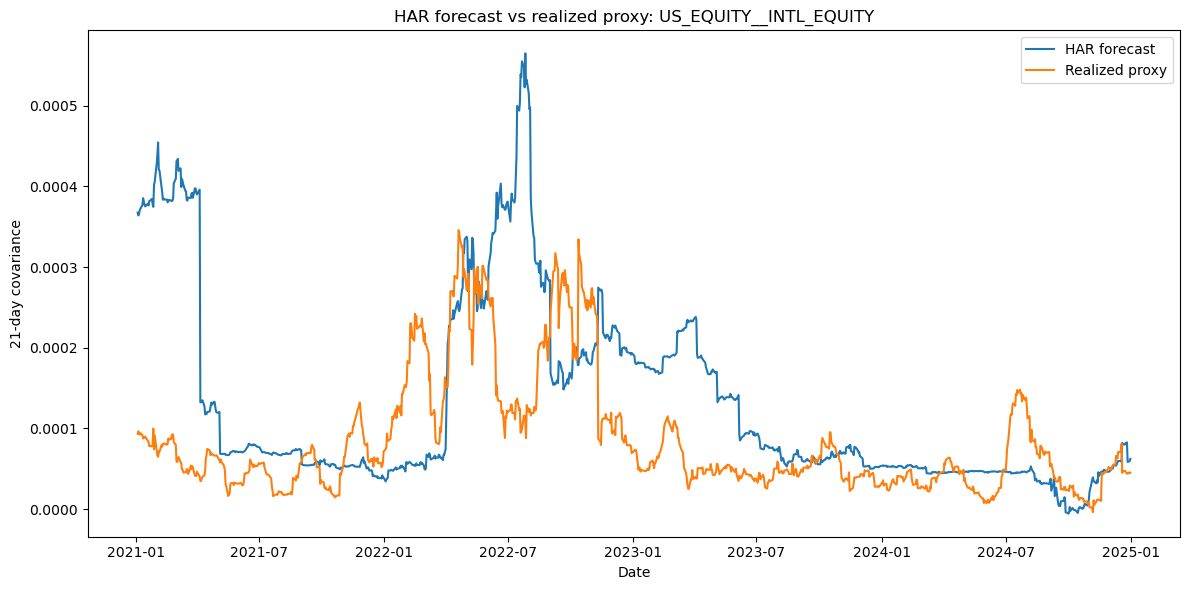


Number of refits: 48
First few refit dates: [Timestamp('2021-01-04 00:00:00'), Timestamp('2021-02-03 00:00:00'), Timestamp('2021-03-05 00:00:00'), Timestamp('2021-04-06 00:00:00'), Timestamp('2021-05-05 00:00:00'), Timestamp('2021-06-04 00:00:00'), Timestamp('2021-07-06 00:00:00'), Timestamp('2021-08-04 00:00:00'), Timestamp('2021-09-02 00:00:00'), Timestamp('2021-10-04 00:00:00')]


In [15]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
har = pd.read_csv(
    "../proxy/realized_cov_har.csv",
    parse_dates=["Date"]
).set_index("Date").sort_index()

proxy = pd.read_csv(
    "../proxy/realized_cov_h21.csv",
    parse_dates=["Date"]
).set_index("Date").sort_index()

# -----------------------------
# Settings
# -----------------------------
y_col = "target_cov_US_EQUITY__INTL_EQUITY"
proxy_col = "cov_US_EQUITY__INTL_EQUITY"

x_cols = [
    "lag5_cov_US_EQUITY__INTL_EQUITY",
    "lag21_cov_US_EQUITY__INTL_EQUITY",
    "lag63_cov_US_EQUITY__INTL_EQUITY"
]

train_window = 252
refit_every = 21

test_start = pd.Timestamp("2021-01-01")
test_end   = pd.Timestamp("2024-12-31")

# Keep only prediction dates that actually exist in both datasets
candidate_dates = har.index[(har.index >= test_start) & (har.index <= test_end)]
candidate_dates = candidate_dates.intersection(proxy.index)

# -----------------------------
# Rolling HAR with refit every 21 rows
# -----------------------------
results = []
model = None
last_refit_pos = None

for p in candidate_dates:
    p_loc = har.index.get_loc(p)

    # Refit on first prediction date, then every 21 rows
    if (model is None) or (last_refit_pos is None) or ((p_loc - last_refit_pos) >= refit_every):
        train_end_loc = p_loc - 21   # last row whose target is fully known at time p
        train_start_loc = train_end_loc - train_window + 1

        # skip if not enough history
        if train_start_loc < 0:
            continue

        train = har.iloc[train_start_loc:train_end_loc + 1].copy()

        y_train = train[y_col]
        X_train = sm.add_constant(train[x_cols], has_constant="add")

        model = sm.OLS(y_train, X_train).fit()
        last_refit_pos = p_loc

        print(
            f"Refit at p = {p.date()} | "
            f"train: {train.index.min().date()} -> {train.index.max().date()} | "
            f"rows: {len(train)}"
        )

    # Predict at p using current fixed model
    x_pred = har.loc[[p], x_cols]
    x_pred = sm.add_constant(x_pred, has_constant="add")

    forecast = model.predict(x_pred).iloc[0]
    realized = proxy.loc[p, proxy_col]

    results.append({
        "Date": p,
        "forecast": forecast,
        "proxy": realized,
        "error": forecast - realized,
        "abs_error": abs(forecast - realized),
        "squared_error": (forecast - realized) ** 2,
        "refit_date": har.index[last_refit_pos]
    })

# -----------------------------
# Collect results
# -----------------------------
results_df = pd.DataFrame(results).set_index("Date").sort_index()

print("\nResult shape:", results_df.shape)
print(results_df.head())

print("\nAverage errors:")
print("MAE :", results_df["abs_error"].mean())
print("MSE :", results_df["squared_error"].mean())

# -----------------------------
# Plot forecast vs proxy
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df["forecast"], label="HAR forecast")
plt.plot(results_df.index, results_df["proxy"], label="Realized proxy")
plt.title("HAR forecast vs realized proxy: US_EQUITY__INTL_EQUITY")
plt.xlabel("Date")
plt.ylabel("21-day covariance")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: show refit dates
# -----------------------------
refit_dates = results_df["refit_date"].drop_duplicates().tolist()
print("\nNumber of refits:", len(refit_dates))
print("First few refit dates:", refit_dates[:10])